# One-Patient Personalized LSTM

This notebook trains a personalized LSTM for **one patient at a time**.

Goal:

- Load `features_dataset_108.csv`.
- Treat the selected CSV as one patient's data.
- Use that patient's previous **7 days** of features.
- Predict that same patient's **next 1 day** of features.
- Train, validate, and test chronologically within that patient.

This is different from a cross-patient model. Here, the model is personalized because it learns from one patient's own history.

## 1. Setup

Generated files are saved in `lstm_npy_outputs/`. The last cell deletes that folder by default so the repo stays clean.

In [1]:
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATA_PATH = Path("features_dataset_77.csv")
OUTPUT_DIR = Path("lstm_npy_outputs")
DELETE_OUTPUTS_AFTER_RUN = True

INPUT_DAYS = 20
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_ACCURACY_TOLERANCE = 0.50  # Accuracy means absolute error <= this normalized value.
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Dataset:", DATA_PATH)

TensorFlow version: 2.21.0
Dataset: features_dataset_77.csv


## 2. Feature List

These are the features used as both input and prediction target.

In [2]:
FEATURE_COLUMNS = [
    "walk_duration",
    "walking_speed",
    "cadence",
    "step_count",
    "left_turn_duration",
    "left_turn_step_count",
    "left_turn_mean_angular_velocity",
    "left_turn_peak_angular_velocity",
    "right_turn_duration",
    "right_turn_step_count",
    "right_turn_mean_angular_velocity",
    "right_turn_peak_angular_velocity",
    "sit_to_stand_flexion_peak",
    "sit_to_stand_extension_peak",
    "stand_to_sit_flexion_peak",
    "stand_to_sit_extension_peak",
]

ID_COLUMNS = ["patient_id", "date"]
KEEP_COLUMNS = ID_COLUMNS + FEATURE_COLUMNS
NUM_FEATURES = len(FEATURE_COLUMNS)

print(f"Number of features: {NUM_FEATURES}")

Number of features: 16


## 3. Load and Check Data

Load the CSV, preview it, and stop if required columns are missing.

In [3]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw_df.shape}")
display(raw_df.head())

missing_columns = [column for column in KEEP_COLUMNS if column not in raw_df.columns]
if missing_columns:
    print("Missing required columns:")
    for column in missing_columns:
        print("-", column)
    raise SystemExit("Fix the missing columns before continuing.")

print("All required columns are present.")

Raw shape: (95, 81)


,patient_id,date,walk_duration,step_count,cadence,walking_speed,mean_step_time,step_time_std,step_time_cv,step_regularity,...,stand_to_sit_flexion_peak,stand_to_sit_extension_peak,stand_to_sit_peak_gyro,stand_to_sit_acc_rms,stand_to_sit_jerk_mean,stand_to_sit_jerk_std,stand_to_sit_peak_count,stand_to_sit_entropy,sitstand_standsit_xcorr_symmetry_score,sitstand_standsit_xcorr_peak_correlation
0,patient_77,2025-04-10,10.9,12.90,77.400,0.917,0.797,0.117,0.147,0.128,...,1.762,-1.194,2.171,0.378,4.884,9.722,14.0,0.293,0.612,-0.612
1,patient_77,2025-04-11,12.9,17.55,81.000,0.775,0.778,0.187,0.240,0.162,...,2.209,-2.615,2.824,0.554,9.940,17.594,17.0,0.404,0.309,0.309
2,patient_77,2025-04-14,9.9,10.45,78.375,1.010,0.798,0.137,0.172,0.008,...,0.806,-2.164,2.263,0.588,14.213,38.683,5.0,0.380,0.445,-0.445
3,patient_77,2025-04-15,9.9,16.50,99.000,1.010,0.606,0.014,0.023,0.137,...,1.617,-1.833,1.952,0.491,7.259,11.804,16.0,0.320,0.301,0.301
4,patient_77,2025-04-16,13.9,19.45,83.357,0.719,0.732,0.094,0.128,0.178,...,0.899,-1.523,1.855,0.342,5.663,11.364,8.0,0.373,0.336,-0.336


All required columns are present.


## 4. Clean Basic Rows

Clean the one-patient feature file.

Steps:

- Remove missing `patient_id` and `date`.
- Parse the real date.
- Keep selected features only.
- Convert features to numbers.

In [4]:
def parse_date(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value)
    match = re.search(r"\d{4}-\d{2}-\d{2}", text)
    if match:
        return pd.to_datetime(match.group(0), errors="coerce")
    return pd.to_datetime(text, errors="coerce")

clean_df = raw_df.copy()
clean_df = clean_df[clean_df["patient_id"].notna()].copy()
clean_df = clean_df[clean_df["date"].notna()].copy()
clean_df["date"] = clean_df["date"].apply(parse_date)
clean_df = clean_df[clean_df["date"].notna()].copy()
clean_df = clean_df[KEEP_COLUMNS].copy()

for column in FEATURE_COLUMNS:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

clean_df = clean_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

print(f"Clean shape: {clean_df.shape}")
print(f"Patients available: {clean_df['patient_id'].nunique()}")
display(clean_df.head())

Clean shape: (95, 18)
Patients available: 1


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak
0,patient_77,2025-04-10,10.9,0.917,77.400,12.90,5.704,9.0,1.022,2.948,5.832,8.0,1.006,2.298,0.395,-6.466,1.762,-1.194
1,patient_77,2025-04-11,12.9,0.775,81.000,17.55,4.203,9.0,0.803,1.791,3.605,8.0,0.851,1.823,1.780,-1.523,2.209,-2.615
2,patient_77,2025-04-14,9.9,1.010,78.375,10.45,10.560,9.0,0.499,1.440,7.035,15.0,0.700,1.732,1.381,-1.402,0.806,-2.164
3,patient_77,2025-04-15,9.9,1.010,99.000,16.50,5.881,12.0,0.763,1.998,5.403,11.0,0.827,2.152,1.130,-1.143,1.617,-1.833
4,patient_77,2025-04-16,13.9,0.719,83.357,19.45,5.821,6.0,0.738,1.562,7.002,14.0,0.722,1.856,1.623,-2.098,0.899,-1.523


## 5. Confirm One Patient in the CSV

This notebook assumes the selected CSV already contains data for exactly one patient.


In [5]:
patient_ids = clean_df["patient_id"].dropna().unique()

if len(patient_ids) == 0:
    raise SystemExit("No patient_id values found after cleaning.")

if len(patient_ids) > 1:
    print("This notebook expects one patient's data per CSV, but found multiple patient IDs:")
    for patient_id in patient_ids:
        print("-", patient_id)
    raise SystemExit("Please use a CSV containing only one patient's data.")

patient_label = str(patient_ids[0])
patient_df = clean_df.copy().sort_values("date").reset_index(drop=True)

print(f"Patient in this CSV: {patient_label}")
print(f"Rows for this patient: {len(patient_df)}")

if len(patient_df) < INPUT_DAYS + 2:
    raise SystemExit(f"This CSV needs at least {INPUT_DAYS + 2} rows for train/test windows.")

display(patient_df.head())

Patient in this CSV: patient_77
Rows for this patient: 95


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak
0,patient_77,2025-04-10,10.9,0.917,77.400,12.90,5.704,9.0,1.022,2.948,5.832,8.0,1.006,2.298,0.395,-6.466,1.762,-1.194
1,patient_77,2025-04-11,12.9,0.775,81.000,17.55,4.203,9.0,0.803,1.791,3.605,8.0,0.851,1.823,1.780,-1.523,2.209,-2.615
2,patient_77,2025-04-14,9.9,1.010,78.375,10.45,10.560,9.0,0.499,1.440,7.035,15.0,0.700,1.732,1.381,-1.402,0.806,-2.164
3,patient_77,2025-04-15,9.9,1.010,99.000,16.50,5.881,12.0,0.763,1.998,5.403,11.0,0.827,2.152,1.130,-1.143,1.617,-1.833
4,patient_77,2025-04-16,13.9,0.719,83.357,19.45,5.821,6.0,0.738,1.562,7.002,14.0,0.722,1.856,1.623,-2.098,0.899,-1.523


## 6. Fill Missing Values for This Patient

For this one patient, fill missing feature values using that patient's feature mean.

If a feature is completely missing for this patient, use the global median from the whole dataset as a fallback.

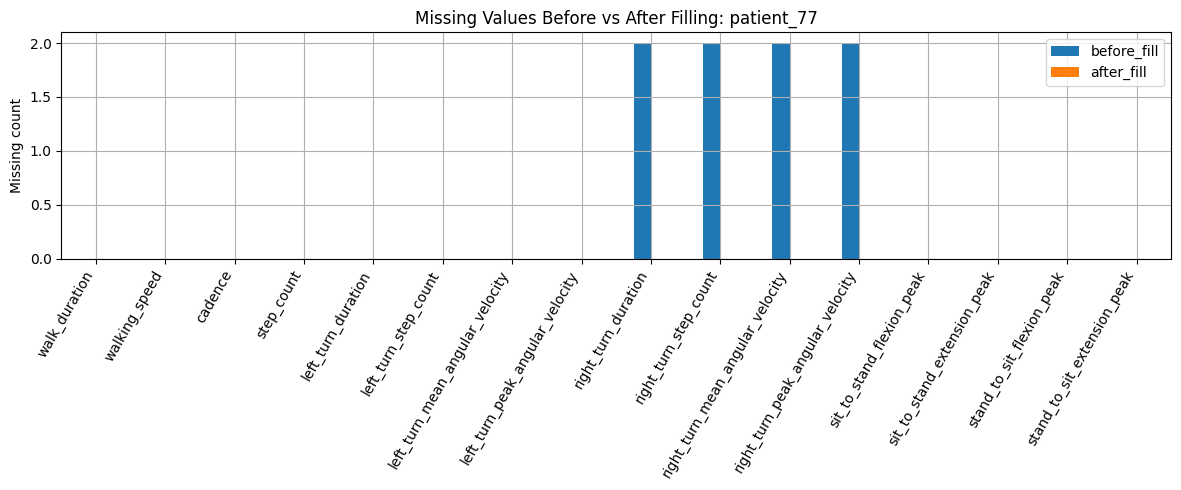

,before_fill,after_fill
walk_duration,0,0
walking_speed,0,0
cadence,0,0
step_count,0,0
left_turn_duration,0,0
left_turn_step_count,0,0
left_turn_mean_angular_velocity,0,0
left_turn_peak_angular_velocity,0,0
right_turn_duration,2,0
right_turn_step_count,2,0


In [6]:
missing_before = patient_df[FEATURE_COLUMNS].isna().sum()

global_feature_medians = clean_df[FEATURE_COLUMNS].median()
patient_feature_means = patient_df[FEATURE_COLUMNS].mean()

filled_patient_df = patient_df.copy()
for feature in FEATURE_COLUMNS:
    fill_value = patient_feature_means[feature]
    if pd.isna(fill_value):
        fill_value = global_feature_medians[feature]
    filled_patient_df[feature] = filled_patient_df[feature].fillna(fill_value)

missing_after = filled_patient_df[FEATURE_COLUMNS].isna().sum()
missing_table = pd.DataFrame({"before_fill": missing_before, "after_fill": missing_after})

missing_table.plot(kind="bar", title=f"Missing Values Before vs After Filling: {patient_label}")
plt.ylabel("Missing count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

display(missing_table)

## 7. Normalize The Patient Data

Normalize using this patient's own mean and standard deviation.

This keeps the model focused on changes relative to the patient's baseline.

In [7]:
normalized_patient_df = filled_patient_df.copy()

feature_means = normalized_patient_df[FEATURE_COLUMNS].mean()
feature_stds = normalized_patient_df[FEATURE_COLUMNS].std().replace(0, 1.0).fillna(1.0)
normalized_patient_df[FEATURE_COLUMNS] = (normalized_patient_df[FEATURE_COLUMNS] - feature_means) / feature_stds

print("Summary after patient-wise normalization:")
display(normalized_patient_df[FEATURE_COLUMNS].describe().T[["mean", "std", "min", "max"]])

Summary after patient-wise normalization:


,mean,std,min,max
walk_duration,-8.274083e-16,1.0,-1.868036,1.177375
walking_speed,-5.025220e-17,1.0,-0.621050,6.886153
cadence,-2.419118e-16,1.0,-5.685794,2.106305
step_count,-2.056834e-16,1.0,-1.969158,4.087112
left_turn_duration,1.542626e-16,1.0,-2.612115,1.320534
left_turn_step_count,-1.308895e-16,1.0,-2.272104,2.339134
left_turn_mean_angular_velocity,-1.098536e-16,1.0,-1.906152,2.964010
left_turn_peak_angular_velocity,-5.457623e-16,1.0,-1.925231,3.501885
right_turn_duration,-3.482594e-16,1.0,-2.813377,1.291295
right_turn_step_count,-3.001985e-17,1.0,-1.971681,2.230925


## 8. Plot Patient Features

Plot a few normalized features over time for the selected patient.

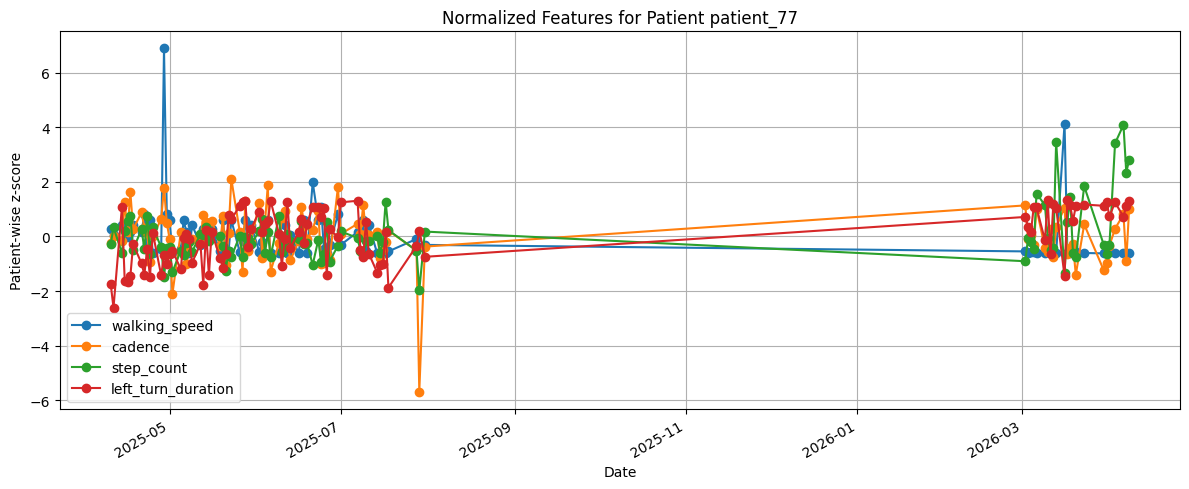

In [8]:
plot_features = ["walking_speed", "cadence", "step_count", "left_turn_duration"]

normalized_patient_df.plot(x="date", y=plot_features, marker="o")
plt.title(f"Normalized Features for Patient {patient_label}")
plt.xlabel("Date")
plt.ylabel("Patient-wise z-score")
plt.tight_layout()
plt.show()

## 9. Build 7-Day Windows

Each sample uses 7 days as input and the next day as the target.

Example:

- Days 1-7 predict day 8.
- Days 2-8 predict day 9.

In [9]:
X_list = []
y_list = []
metadata_rows = []

values = normalized_patient_df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
dates = normalized_patient_df["date"].to_numpy()

for start in range(0, len(values) - INPUT_DAYS):
    end = start + INPUT_DAYS
    X_list.append(values[start:end])
    y_list.append(values[end])
    metadata_rows.append({
        "patient_id": patient_label,
        "window_index": start,
        "input_start_date": dates[start],
        "input_end_date": dates[end - 1],
        "target_date": dates[end],
    })

X_all = np.stack(X_list).astype(np.float32)
y_all = np.stack(y_list).astype(np.float32)
window_metadata = pd.DataFrame(metadata_rows)

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
display(window_metadata.head())

X_all shape: (75, 20, 16)
y_all shape: (75, 16)


,patient_id,window_index,input_start_date,input_end_date,target_date
0,patient_77,0,2025-04-10,2025-05-07,2025-05-08
1,patient_77,1,2025-04-11,2025-05-08,2025-05-09
2,patient_77,2,2025-04-14,2025-05-09,2025-05-12
3,patient_77,3,2025-04-15,2025-05-12,2025-05-13
4,patient_77,4,2025-04-16,2025-05-13,2025-05-14


## 10. Chronological Train / Validation / Test Split

For one patient, we split by time, not randomly.

Earlier windows train the model. Later windows test whether it predicts the patient's future.

In [10]:
n_samples = len(X_all)
train_end = max(1, int(n_samples * TRAIN_FRACTION))
val_end = max(train_end + 1, int(n_samples * (TRAIN_FRACTION + VAL_FRACTION)))

# Keep at least one test sample when possible.
if val_end >= n_samples:
    val_end = n_samples - 1
if train_end >= val_end:
    train_end = max(1, val_end - 1)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

train_metadata = window_metadata.iloc[:train_end].reset_index(drop=True)
val_metadata = window_metadata.iloc[train_end:val_end].reset_index(drop=True)
test_metadata = window_metadata.iloc[val_end:].reset_index(drop=True)

print(f"Total windows: {n_samples}")
print(f"Train windows: {len(X_train)}")
print(f"Validation windows: {len(X_val)}")
print(f"Test windows: {len(X_test)}")
print()
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

if len(X_train) == 0 or len(X_test) == 0:
    raise SystemExit("Not enough windows for LSTM training and testing. Choose a patient with more rows.")

Total windows: 75
Train windows: 52
Validation windows: 11
Test windows: 12

X_train: (52, 20, 16)  y_train: (52, 16)
X_val:   (11, 20, 16)  y_val:   (11, 16)
X_test:  (12, 20, 16)  y_test:  (12, 16)


## 11. Save Prepared Arrays

Save arrays and metadata in `lstm_npy_outputs/`.

In [11]:
normalized_patient_df.to_csv(OUTPUT_DIR / "personalized_cleaned_features.csv", index=False)
window_metadata.to_csv(OUTPUT_DIR / "window_metadata.csv", index=False)
train_metadata.to_csv(OUTPUT_DIR / "train_metadata.csv", index=False)
val_metadata.to_csv(OUTPUT_DIR / "val_metadata.csv", index=False)
test_metadata.to_csv(OUTPUT_DIR / "test_metadata.csv", index=False)

np.save(OUTPUT_DIR / "X_train.npy", X_train)
np.save(OUTPUT_DIR / "y_train.npy", y_train)
np.save(OUTPUT_DIR / "X_val.npy", X_val)
np.save(OUTPUT_DIR / "y_val.npy", y_val)
np.save(OUTPUT_DIR / "X_test.npy", X_test)
np.save(OUTPUT_DIR / "y_test.npy", y_test)

print(f"Saved files in: {OUTPUT_DIR.resolve()}")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.name}")

Saved files in: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/lstm_npy_outputs
- X_test.npy
- X_train.npy
- X_val.npy
- personalized_cleaned_features.csv
- test_metadata.csv
- train_metadata.csv
- val_metadata.csv
- window_metadata.csv
- y_test.npy
- y_train.npy
- y_val.npy


## 12. Baseline MAE

Before training the LSTM, compare against a simple baseline:

The next day is predicted as equal to the last input day.

In [12]:
baseline_pred = X_test[:, -1, :]
baseline_errors = np.abs(baseline_pred - y_test)

print(f"Baseline test MAE: {baseline_errors.mean():.4f}")

baseline_table = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "baseline_mae": baseline_errors.mean(axis=0),
})
display(baseline_table)

Baseline test MAE: 0.8182


,feature,baseline_mae
0,walk_duration,0.474314
1,walking_speed,0.443329
2,cadence,1.034986
3,step_count,1.424587
4,left_turn_duration,0.537122
5,left_turn_step_count,1.299198
6,left_turn_mean_angular_velocity,0.500073
7,left_turn_peak_angular_velocity,0.796559
8,right_turn_duration,0.499402
9,right_turn_step_count,1.216544


## 13. Train Required LSTM

This LSTM is compulsory in this notebook.

Architecture:

- One LSTM layer with 64 units.
- One Dense layer with one output per feature.
- Loss: MAE.
- Optimizer: Adam.

In [13]:
model = keras.Sequential([
    layers.Input(shape=(INPUT_DAYS, NUM_FEATURES)),
    layers.LSTM(64),
    layers.Dense(NUM_FEATURES),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mae",
    metrics=["mae"],
)

model.summary()

fit_kwargs = {
    "x": X_train,
    "y": y_train,
    "epochs": 50,
    "batch_size": min(16, max(1, len(X_train))),
    "verbose": 1,
}

if len(X_val) > 0:
    fit_kwargs["validation_data"] = (X_val, y_val)

history = model.fit(**fit_kwargs)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,776 (85.06 KB)

 Trainable params: 21,776 (85.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.6673 - mae: 0.6673 - val_loss: 0.9086 - val_mae: 0.9086
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6406 - mae: 0.6406 - val_loss: 0.9024 - val_mae: 0.9024
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6234 - mae: 0.6234 - val_loss: 0.8985 - val_mae: 0.8985
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6109 - mae: 0.6109 - val_loss: 0.8971 - val_mae: 0.8971
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6037 - mae: 0.6037 - val_loss: 0.8970 - val_mae: 0.8970
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5988 - mae: 0.5988 - val_loss: 0.8969 - val_mae: 0.8969
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5937 - mae: 0.5937 - val_loss: 0.8970 - val_mae: 0.8970
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5889 - mae: 0.5889 - val_loss: 0.8982 - val_mae: 0.8982
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5849 - mae: 0.5849 - val_loss

## 14. Plot LSTM Loss

This shows whether the model's training loss is improving.

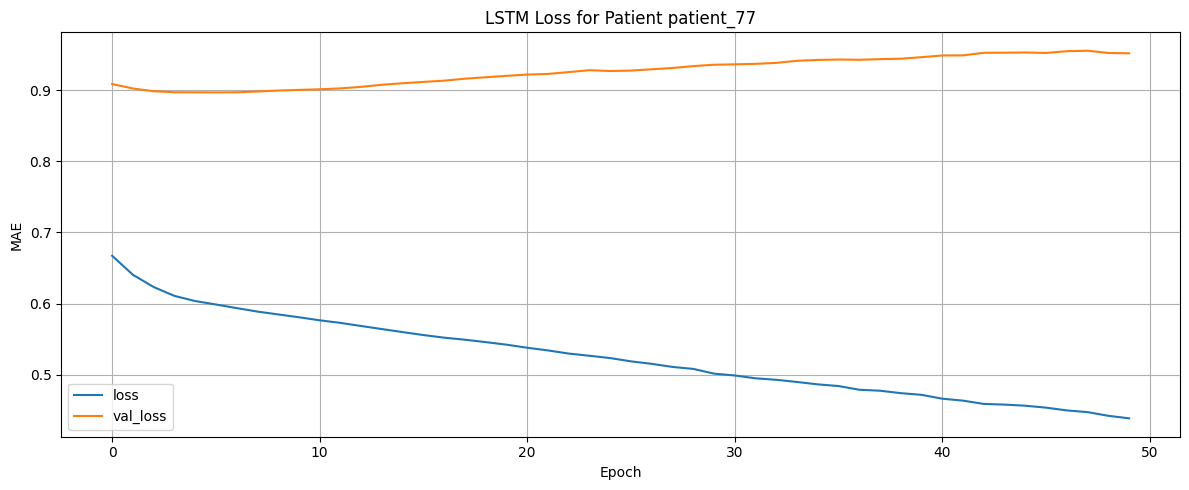

,loss,mae,val_loss,val_mae
45,0.453818,0.453818,0.952339,0.952339
46,0.449936,0.449936,0.954810,0.954810
47,0.447536,0.447536,0.955497,0.955497
48,0.442342,0.442342,0.952310,0.952310
49,0.438801,0.438801,0.951853,0.951853


In [14]:
history_df = pd.DataFrame(history.history)
history_df[[column for column in ["loss", "val_loss"] if column in history_df.columns]].plot()
plt.title(f"LSTM Loss for Patient {patient_label}")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

display(history_df.tail())

## 15. Evaluate LSTM and Generalization Error

Evaluate the trained personalized LSTM on the patient's future test windows.

The generalization error highlights how much worse the model performs on future test data compared with training data.

In [15]:
pred_train = model.predict(X_train, verbose=0)
pred_test = model.predict(X_test, verbose=0)

train_mae = np.mean(np.abs(pred_train - y_train))
train_mse = np.mean((pred_train - y_train) ** 2)
test_abs_errors = np.abs(pred_test - y_test)
test_mae = np.mean(test_abs_errors)
test_mse = np.mean((pred_test - y_test) ** 2)
test_accuracy = np.mean(test_abs_errors <= TEST_ACCURACY_TOLERANCE)

if len(X_val) > 0:
    pred_val = model.predict(X_val, verbose=0)
    val_mae = np.mean(np.abs(pred_val - y_val))
    val_mse = np.mean((pred_val - y_val) ** 2)
else:
    val_mae = np.nan
    val_mse = np.nan

baseline_mae = baseline_errors.mean()
baseline_mse = np.mean((baseline_pred - y_test) ** 2)

print(f"LSTM test MAE: {test_mae:.4f}")
print(f"LSTM test MSE: {test_mse:.4f}")
print(f"LSTM test accuracy within +/- {TEST_ACCURACY_TOLERANCE:.2f}: {test_accuracy:.2%}")
print(f"Baseline test MAE: {baseline_mae:.4f}")
print(f"Baseline test MSE: {baseline_mse:.4f}")

generalization_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "MAE": [train_mae, val_mae, test_mae],
    "MSE": [train_mse, val_mse, test_mse],
})
generalization_table["MSE_gap_vs_train"] = generalization_table["MSE"] - train_mse

def highlight_generalization_gap(row):
    if row["split"] == "test" and row["MSE_gap_vs_train"] > 0:
        return ["background-color: #ffd6d6"] * len(row)
    return [""] * len(row)

print("Generalization error is the test MSE minus the train MSE.")
display(
    generalization_table
    .style
    .apply(highlight_generalization_gap, axis=1)
    .format({"MAE": "{:.4f}", "MSE": "{:.4f}", "MSE_gap_vs_train": "{:.4f}"})
)

per_feature_mae = np.mean(np.abs(pred_test - y_test), axis=0)
per_feature_mse = np.mean((pred_test - y_test) ** 2, axis=0)

error_table = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "baseline_mae": baseline_errors.mean(axis=0),
    "lstm_mae": per_feature_mae,
    "lstm_mse": per_feature_mse,
})
error_table["lstm_minus_baseline_mae"] = error_table["lstm_mae"] - error_table["baseline_mae"]
display(error_table)

LSTM test MAE: 0.8235
LSTM test MSE: 1.0788
LSTM test accuracy within +/- 0.50: 32.29%
Baseline test MAE: 0.8182
Baseline test MSE: 1.4207
Generalization error is the test MSE minus the train MSE.


,split,MAE,MSE,MSE_gap_vs_train
0,train,0.4387,0.5086,0.0000
1,validation,0.9519,1.5435,1.0348
2,test,0.8235,1.0788,0.5702


,feature,baseline_mae,lstm_mae,lstm_mse,lstm_minus_baseline_mae
0,walk_duration,0.474314,0.845157,0.766447,0.370843
1,walking_speed,0.443329,0.700733,0.516638,0.257405
2,cadence,1.034986,0.621044,0.564267,-0.413942
3,step_count,1.424587,1.603342,3.609433,0.178755
4,left_turn_duration,0.537122,1.093242,1.274856,0.556120
5,left_turn_step_count,1.299198,1.600498,2.840424,0.301300
6,left_turn_mean_angular_velocity,0.500073,0.628430,0.479549,0.128357
7,left_turn_peak_angular_velocity,0.796559,0.554272,0.657613,-0.242287
8,right_turn_duration,0.499402,0.557913,0.397582,0.058511
9,right_turn_step_count,1.216544,0.992067,1.364788,-0.224477


## 16. Plot One Prediction

Visualize one test prediction: 7 input days, true next day, and predicted next day.

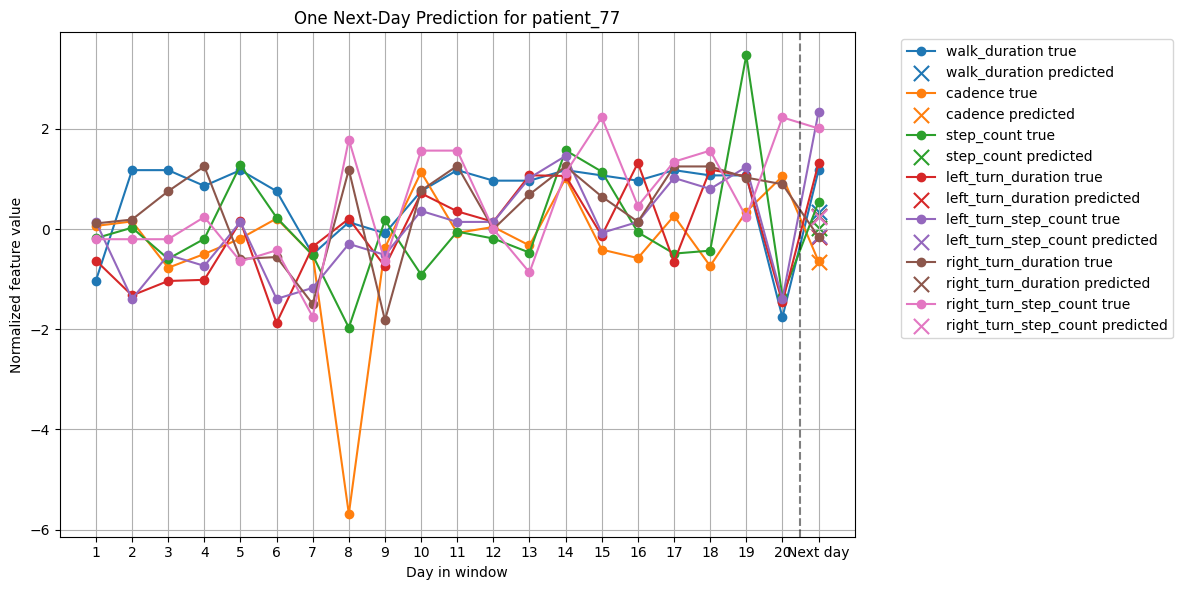

In [16]:
sample_index = 0
sample_X = X_test[sample_index:sample_index + 1]
sample_y_true = y_test[sample_index]
sample_y_pred = model.predict(sample_X, verbose=0)[0]

features_to_plot = [
    "walk_duration",
    "cadence",
    "step_count",
    "left_turn_duration",
    "left_turn_step_count",
    "right_turn_duration",
    "right_turn_step_count",
]
feature_indices = [FEATURE_COLUMNS.index(feature) for feature in features_to_plot]

x_days = np.arange(1, INPUT_DAYS + 2)

plt.figure(figsize=(12, 6))
for feature, feature_idx in zip(features_to_plot, feature_indices):
    input_values = sample_X[0, :, feature_idx]
    true_series = np.concatenate([input_values, [sample_y_true[feature_idx]]])
    predicted_next = sample_y_pred[feature_idx]

    plt.plot(x_days, true_series, marker="o", label=f"{feature} true")
    plt.scatter(INPUT_DAYS + 1, predicted_next, marker="x", s=120, label=f"{feature} predicted")

plt.axvline(INPUT_DAYS + 0.5, linestyle="--", color="black", alpha=0.5)
plt.title(f"One Next-Day Prediction for {patient_label}")
plt.xlabel("Day in window")
plt.ylabel("Normalized feature value")
plt.xticks(x_days, [f"{i}" for i in range(1, INPUT_DAYS + 1)] + ["Next day"])
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 17. Predicted vs Actual Next-Day Values

This table shows the LSTM prediction for **all features** for the selected test sample.

It includes both normalized values and unnormalized values converted back to the original feature scale.

In [17]:
feature_mean_values = feature_means[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
feature_std_values = feature_stds[FEATURE_COLUMNS].to_numpy(dtype=np.float32)

sample_y_true_original = (sample_y_true * feature_std_values) + feature_mean_values
sample_y_pred_original = (sample_y_pred * feature_std_values) + feature_mean_values

prediction_table = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "actual_next_day_normalized": sample_y_true,
    "predicted_next_day_normalized": sample_y_pred,
    "actual_next_day_original": sample_y_true_original,
    "predicted_next_day_original": sample_y_pred_original,
})

prediction_table["absolute_error_normalized"] = (
    prediction_table["predicted_next_day_normalized"] - prediction_table["actual_next_day_normalized"]
).abs()

prediction_table["within_accuracy_tolerance"] = (
    prediction_table["absolute_error_normalized"] <= TEST_ACCURACY_TOLERANCE
)

sample_accuracy = prediction_table["within_accuracy_tolerance"].mean()
print(f"Sample accuracy within +/- {TEST_ACCURACY_TOLERANCE:.2f}: {sample_accuracy:.2%}")

display(
    prediction_table
    .style
    .format({
        "actual_next_day_normalized": "{:.4f}",
        "predicted_next_day_normalized": "{:.4f}",
        "actual_next_day_original": "{:.4f}",
        "predicted_next_day_original": "{:.4f}",
        "absolute_error_normalized": "{:.4f}",
    })
    .background_gradient(subset=["absolute_error_normalized"], cmap="Reds")
)

Sample accuracy within +/- 0.50: 43.75%


,feature,actual_next_day_normalized,predicted_next_day_normalized,actual_next_day_original,predicted_next_day_original,absolute_error_normalized,within_accuracy_tolerance
0,walk_duration,1.1774,0.3446,30.9000,22.9701,0.8327,False
1,walking_speed,-0.6210,-0.1252,0.3240,0.6502,0.4958,True
2,cadence,-0.6446,-0.6476,71.8130,71.7696,0.0030,True
3,step_count,0.5385,0.0269,19.1500,15.2431,0.5116,False
4,left_turn_duration,1.3188,-0.1665,10.9860,8.4230,1.4853,False
5,left_turn_step_count,2.3391,-0.1393,27.0000,15.7132,2.4784,False
6,left_turn_mean_angular_velocity,0.9610,0.0467,0.7740,0.6608,0.9144,False
7,left_turn_peak_angular_velocity,0.8601,0.5470,2.2050,2.0938,0.3132,True
8,right_turn_duration,-0.1546,0.2652,8.3660,9.1177,0.4198,True
9,right_turn_step_count,2.0097,0.2350,26.0000,17.9764,1.7747,False


## 18. Cleanup

Delete the generated output folder by default.

Set `DELETE_OUTPUTS_AFTER_RUN = False` in the setup cell if you want to keep the `.npy` files and metadata.

In [18]:
if DELETE_OUTPUTS_AFTER_RUN:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
    print(f"Deleted generated output folder: {OUTPUT_DIR}")
else:
    print(f"Kept generated output folder: {OUTPUT_DIR.resolve()}")

Deleted generated output folder: lstm_npy_outputs
